
# t-SNE Workflow for HDF5 Datasets (`phi` features, `target` labels)

This notebook loads one or more `.h5` files, where:
- **`phi`** contains the features (shape: `n_samples x n_features`).
- **`target`** contains the binary labels (shape: `n_samples` or `n_samples x 1`).

It then:
1. (Optionally) standardizes features and applies PCA (recommended for large/noisy data).
2. Runs **t-SNE** to produce a 2D or 3D embedding.
3. Plots the projection colored by the `target` label.
4. Saves the embedding (CSV) and the plot (PNG) to disk.

> Note: This notebook uses **matplotlib** for plotting (no seaborn), and makes one plot per cell.


In [5]:

# Imports & environment check
import os
import glob
import h5py
import numpy as np
import matplotlib.pyplot as plt

from typing import List, Tuple, Optional
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Optional: print versions
import sys
print(f"Python: {sys.version.split()[0]}")
try:
    import sklearn
    print(f"scikit-learn: {sklearn.__version__}")
except Exception as e:
    print("scikit-learn not found.", e)
try:
    import h5py as _h5py
    print(f"h5py: {_h5py.__version__}")
except Exception as e:
    print("h5py not found.", e)


Python: 3.10.18
scikit-learn: 1.7.1
h5py: 3.14.0



## Parameters

- `FILE_PATHS`: list of HDF5 files to load. Each must contain datasets `phi` and `target`.
- `N_COMPONENTS`: 2 for 2D plot, 3 for 3D.
- `STANDARDIZE`: standardize features before t-SNE (recommended).
- `PCA_FIRST`: apply PCA before t-SNE (can speed up and denoise).
- `PCA_COMPONENTS`: if `None`, picks `min(50, n_features)` automatically.


In [6]:

# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
# TODO: Set your HDF5 paths here. You can pass one or multiple files.
# Example: FILE_PATHS = ["/mnt/data/your_file1.h5", "/mnt/data/your_file2.h5"]
# <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
FILE_PATHS = glob.glob("/Users/aschuetz/Documents/Analysis/bbh/resolve/examples/binary-black-hole/in/data/lf/v1.3/training_cnp/COMPAS_5000_99*_resum.h5")  # auto-discover in /mnt/data; replace as needed

# t-SNE settings
N_COMPONENTS = 2          # 2 or 3
STANDARDIZE = True        # Recommended in most cases
PCA_FIRST = False         # Set True if data is very noisy or very high-dimensional
PCA_COMPONENTS = None     # None -> choose automatically
RANDOM_STATE = 42         # for reproducibility



## Utilities
Functions to load data and to select sensible t-SNE parameters.


In [7]:

from typing import List, Tuple, Optional

def load_h5_phi_target(paths: List[str]) -> Tuple[np.ndarray, Optional[np.ndarray]]:
    """Load and concatenate 'phi' (features) and 'target' (labels) from a list of HDF5 files."""
    X_list = []
    y_list = []
    for p in paths[:1]:
        try:
            with h5py.File(p, "r") as f:
                print(f"Reading {p}...")
                if "phi" not in f or "target" not in f:
                    print(f"[WARN] {p} missing required keys 'phi' and/or 'target'. Skipping.")
                    continue
                #selected_labels=["CH_on_MS(1)","CH_on_MS(2)","Eccentricity@ZAMS","Equilibrated_At_Birth","Evolution_Status","Mass@ZAMS(1)","Mass@ZAMS(2)","Merger","Merger_At_Birth","Metallicity@ZAMS(1)","Metallicity@ZAMS(2)","Omega@ZAMS(1)","Omega@ZAMS(2)","PO_CE_Alpha","PO_LBV_Factor","PO_Sigma_Kick_CCSN_BH","PO_Sigma_Kick_CCSN_NS","PO_Sigma_Kick_ECSN","PO_Sigma_Kick_USSN","PO_WR_Factor","SN_Kick_Magnitude_Random_N","SemiMajorAxis@ZAMS","Stellar_Type(1)","Stellar_Type(2)","Stellar_Type@ZAMS(1)","Stellar_Type@ZAMS(2)"]
                selected_labels=["CH_on_MS(1)","CH_on_MS(2)","Eccentricity@ZAMS","Equilibrated_At_Birth","Evolution_Status","Mass@ZAMS(1)","Mass@ZAMS(2)","Merger","Merger_At_Birth","Metallicity@ZAMS(1)","Metallicity@ZAMS(2)","Omega@ZAMS(1)","Omega@ZAMS(2)","PO_CE_Alpha","PO_LBV_Factor","PO_Sigma_Kick_ECSN","PO_Sigma_Kick_USSN","PO_WR_Factor","SN_Kick_Magnitude_Random_N","SemiMajorAxis@ZAMS","Stellar_Type(1)","Stellar_Type(2)","Stellar_Type@ZAMS(1)","Stellar_Type@ZAMS(2)"]
                
                labels = list(map(lambda x: x.decode() if isinstance(x, bytes) else x, f['phi_labels'][:]))
                # Find indices of required columns **before** reading phi
                selected_indices = [labels.index(label) for label in selected_labels if label in labels]
                X_phi = np.array(f["phi"][:])  # shape (n_samples, n_features)
                X_phi = X_phi[:, selected_indices]
                X = np.array(f["phi"][:])
                X = X[:, selected_indices]
                # Repeat theta row to match sample count
                n = X_phi.shape[0]

                theta = np.array(f["theta"][:]).reshape(1, -1)

                theta_repeated = np.repeat(theta, n, axis=0)   # shape (n, 4)

                # Concatenate to phi along feature axis
                X = np.hstack([X_phi, theta_repeated])   # shape (n, n_features+4)

                # Read the target matrix and label names
                targets = np.array(f["target"][:])          # shape: (n_samples, n_targets)
                target_labels = [t.decode("utf-8") if isinstance(t, bytes) else str(t) 
                                for t in f["target_headers"][:]]
                print("Available target labels:", target_labels)

                # Find the index of the label you want
                label_name = "BBH Events"
                idx = target_labels.index(label_name)

                # Select only that column
                y = targets[:, idx]
                y = y.reshape(-1)  # flatten to 1D if needed
                if X.shape[0] != y.shape[0]:
                    print(f"[WARN] {p}: 'phi' rows ({X.shape[0]}) != 'target' len ({y.shape[0]}). Skipping.")
                    continue
                X_list.append(X)
                y_list.append(y)
        except Exception as e:
            print(f"[ERROR] Failed to read {p}: {e}")
    if not X_list:
        return np.array([]), None
    X_all = np.vstack(X_list)
    y_all = np.concatenate(y_list)
    return X_all, y_all

def heuristic_perplexity(n_samples: int) -> int:
    """Choose a safe t-SNE perplexity based on sample size."""
    # Rule of thumb: perplexity in [5, 50], and < n_samples/3
    if n_samples < 10:
        return 5
    max_allowed = max(5, int(n_samples / 3) - 1)
    return int(np.clip(30, 5, min(50, max_allowed)))



## Load Data & Quick Checks
This cell loads the HDF5 files and prints basic info (shapes and class balance).


In [8]:

X, y = load_h5_phi_target(FILE_PATHS)

Reading /Users/aschuetz/Documents/Analysis/bbh/resolve/examples/binary-black-hole/in/data/lf/v1.3/training_cnp/COMPAS_5000_993_resum.h5...
Available target labels: ['DCOs', 'BBH Events']


In [9]:

print(f"Loaded data from {len(FILE_PATHS)} files.")
if X.size == 0 or y is None:
    raise RuntimeError("No valid data loaded. Check `FILE_PATHS` and ensure each file has 'phi' and 'target'.")

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique labels:", np.unique(y, return_counts=True))


Loaded data from 11 files.
X shape: (5000, 28)
y shape: (5000,)
Unique labels: (array([0., 1.]), array([4938,   62]))



## Preprocessing (Optional)
- **Standardization**: zero-mean/unit-variance scaling of features.
- **PCA**: reduce to a smaller number of components before t-SNE (often helps speed & stability).



X_proc = X.copy()

# Standardize
if STANDARDIZE:
    scaler = StandardScaler()
    X_proc = scaler.fit_transform(X_proc)

# PCA (optional)
if PCA_FIRST:
    n_features = X_proc.shape[1]
    n_pca = PCA_COMPONENTS if PCA_COMPONENTS is not None else min(50, n_features)
    pca = PCA(n_components=n_pca, random_state=RANDOM_STATE)
    X_proc = pca.fit_transform(X_proc)
    print(f"Applied PCA to {n_pca} components.")
else:
    print("PCA not applied.")



## Run t-SNE
This cell runs t-SNE and stores the 2D/3D embedding in `X_embedded`. It also saves:
- A PNG figure (`tsne_projection_2d.png` or `tsne_projection_3d.png`).
- A CSV with the embedding and labels (`tsne_embedding.csv`).



perp = heuristic_perplexity(X_proc.shape[0])
print(f"Using perplexity={perp} for n_samples={X_proc.shape[0]}.")

tsne = TSNE(n_components=N_COMPONENTS, random_state=RANDOM_STATE, perplexity=perp, init="pca")
X_embedded = tsne.fit_transform(X_proc)

# Save embedding + labels to CSV
import csv
csv_path = "tsne_embedding.csv"
with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    header = [f"tsne_{i+1}" for i in range(N_COMPONENTS)] + ["target"]
    writer.writerow(header)
    for i in range(X_embedded.shape[0]):
        row = list(X_embedded[i]) + [y[i]]
        writer.writerow(row)
print(f"Saved embedding CSV to {csv_path}")



## Plot the Embedding
- If `N_COMPONENTS = 2`: a 2D scatter is drawn.
- If `N_COMPONENTS = 3`: a 3D scatter is drawn.



if N_COMPONENTS == 2:
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y, alpha=0.75)
    plt.title("t-SNE projection (colored by target)")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    cbar = plt.colorbar(scatter)
    cbar.set_label("target")
    out_path = "tsne_projection_2d.png"
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.show()
    print(f"Saved plot to {out_path}")
elif N_COMPONENTS == 3:
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection='3d')
    p = ax.scatter(X_embedded[:, 0], X_embedded[:, 1], X_embedded[:, 2], c=y, alpha=0.75)
    ax.set_title("t-SNE projection (3D, colored by target)")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.set_zlabel("t-SNE 3")
    fig.colorbar(p, ax=ax, label="target")
    out_path = "/mnt/data/tsne_projection_3d.png"
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.show()
    print(f"Saved plot to {out_path}")
else:
    print("N_COMPONENTS must be 2 or 3 to plot.")


# y is shape (n_samples,), values in {0,1}
mask0 = (y == 0)
mask1 = (y == 1)

plt.figure(figsize=(8,6))
plt.scatter(X_embedded[mask0, 0], X_embedded[mask0, 1],
            s=10, alpha=0.5, marker='o', label='Class 0', zorder=1)
plt.scatter(X_embedded[mask1, 0], X_embedded[mask1, 1],
            s=14, alpha=0.8, marker='^', label='Class 1', zorder=2)
plt.legend(title="Target")
plt.title("t-SNE (masked classes)")
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
plt.tight_layout(); plt.show()


## (Optional) UMAP
If you prefer UMAP, uncomment and run the following cell. You may need to install `umap-learn` first.

```python
# !pip install umap-learn
import umap
umap_model = umap.UMAP(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_umap = umap_model.fit_transform(X_proc)
# Plot similarly with matplotlib...
```


In [10]:
#from sklearn.utils import shuffle
#X_shuf, y_shuf = shuffle(X, y, random_state=42)

In [11]:

import umap
import matplotlib.pyplot as plt

# Suppose X (features) and y (labels) are already loaded
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_umap = reducer.fit_transform(X)


/Users/aschuetz/.local/modules/miniconda/miniconda3/envs/resolve/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


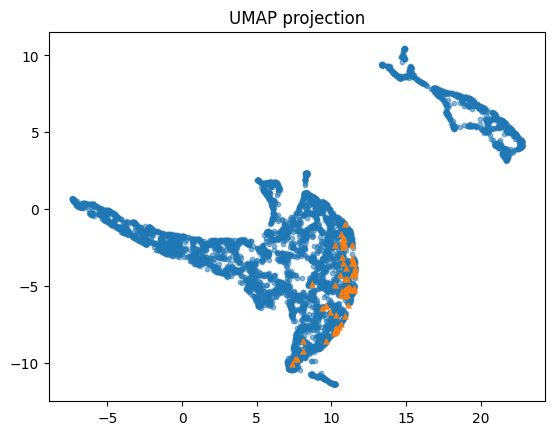

In [12]:
# Suppose X (features) and y (labels) are already loaded

mask0 = (y == 0)
mask1 = (y == 1)

plt.scatter(X_umap[mask0, 0], X_umap[mask0, 1],
            s=10, alpha=0.5, marker='o', label='Class 0', zorder=1)
plt.scatter(X_umap[mask1, 0], X_umap[mask1, 1],
            s=14, alpha=0.8, marker='^', label='Class 1', zorder=2)
plt.title("UMAP projection")
plt.show()


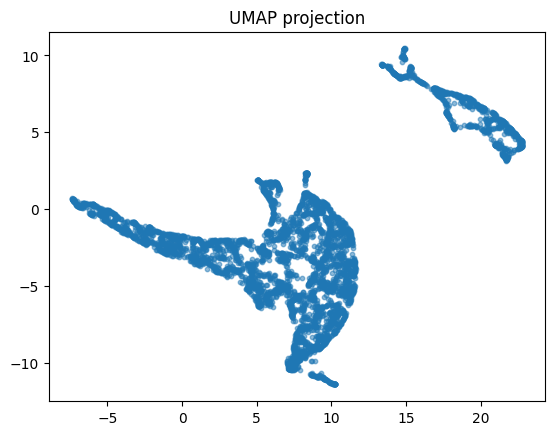

In [13]:
for i,f in enumerate(FILE_PATHS):
    id=int(i)
    plt.scatter(X_umap[:, 0][id*5000:(id+1)*5000], X_umap[:, 1][id*5000:(id+1)*5000],
            s=10+id, alpha=0.5, marker='o', label=f'Class {i}', zorder=0)

plt.title("UMAP projection")
plt.show()

In [16]:
import pandas as pd
df = pd.DataFrame(X)
df.to_csv("tmp.csv")